# 🔗 Módulo 2.2: Modelos Lineales
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 10 horas

---

## 🎯 Objetivos del Módulo

Los modelos lineales son la base del Machine Learning. Son interpretables, eficientes y la base de muchos algoritmos más complejos. En este módulo, dominarás las técnicas lineales tanto para regresión como para clasificación.

Al finalizar, serás capaz de:

- ✅ Implementar y entender la **Regresión Lineal Múltiple** para predecir valores a partir de múltiples características.
- ✅ Utilizar la **Regresión Logística** como un potente y fundamental modelo de clasificación.
- ✅ Comprender el concepto de **Regularización** como una técnica clave para combatir el overfitting.
- ✅ Aplicar la regularización **Ridge (L2)** y **Lasso (L1)** para crear modelos más robustos.
- ✅ Interpretar los coeficientes de los modelos lineales para extraer conclusiones de negocio.

**¡Prepárate para construir modelos que no solo predicen, sino que también explican!**

---

## 📚 Tabla de Contenidos

1. [Regresión Lineal Múltiple](#1-reg-multiple)
   - [Más Allá de una Sola Variable](#1.1-mas-alla)
   - [Implementación y Análisis de Coeficientes](#1.2-implementacion)
2. [Regresión Logística para Clasificación](#2-reg-logistica)
   - [De la Línea a la Probabilidad: La Función Sigmoide](#2.1-sigmoide)
   - [Implementación y Toma de Decisiones](#2.2-implementacion-log)
3. [El Problema del Overfitting en Modelos Lineales](#3-overfitting)
   - [Cuando los Coeficientes se Vuelven Locos: Multicolinealidad](#3.1-multi)
4. [Regularización: Domando la Complejidad](#4-regularizacion)
   - [La Idea: Penalizar la Complejidad](#4.1-idea)
   - [Regresión Ridge (Regularización L2)](#4.2-ridge)
   - [Regresión Lasso (Regularización L1)](#4.3-lasso)
   - [Comparativa: Ridge vs. Lasso](#4.4-comparativa)
5. [Resumen y Próximos Pasos](#5-resumen)

---

## 🏡 1. Regresión Lineal Múltiple <a id='1-reg-multiple'></a>

### 1.1 Más Allá de una Sola Variable <a id='1.1-mas-alla'></a>

En el módulo anterior, predijimos el precio de una casa basándonos solo en su tamaño. Pero en el mundo real, el precio depende de muchos más factores: número de habitaciones, antigüedad, ubicación, etc.

La **Regresión Lineal Múltiple** extiende la regresión lineal simple para incorporar múltiples variables predictoras (características).

**Ecuación del Modelo:**
$$ \text{Precio} = \beta_0 + \beta_1 \times \text{Tamaño} + \beta_2 \times \text{Nº Habitaciones} + \beta_3 \times \text{Antigüedad} + \dots + \epsilon $$

- **β₀**: Es el intercepto, el precio base si todas las demás características fueran cero.
- **β₁, β₂, β₃...**: Son los **coeficientes** del modelo. Cada `βᵢ` representa el cambio en el precio por cada unidad de aumento en la característica `i`, **manteniendo todas las demás constantes**.

La interpretación de estos coeficientes es extremadamente útil para entender qué factores influyen más en el resultado.

🏠 IMAGINEMOS QUE QUEREMOS PREDECIR EL PRECIO DE UNA CASA

🔹 REGRESIÓN LINEAL SIMPLE (1 variable):
   Solo mirábamos el TAMAÑO de la casa
   Precio = ? + (algo × Tamaño)
   ❌ Pero... ¿y si la casa tiene muchas habitaciones?
   ❌ ¿Y si es muy antigua?

🔹 REGRESIÓN LINEAL MÚLTIPLE (varias variables):
   Ahora miramos VARIOS factores a la vez:
   • Tamaño (m²)
   • Número de habitaciones
   • Antigüedad (años)
   ✅ ¡Mucho más realista!

🧮 LOS INGREDIENTES DE LA FÓRMULA


📌 INTERCEPTO (β₀):
   • Es el 'precio base' de partida
   • Imagina una casa hipotética con:
     - 0 m² (no existe, pero matemáticamente...)
     - 0 habitaciones
     - 0 años de antigüedad
   • Es el punto de partida antes de añadir las características
   • Ejemplo: β₀ = 10,000€


📌 COEFICIENTES (β₁, β₂, β₃...):
   • Son los 'multiplicadores' de cada característica
   • Nos dicen: ¿cuánto SUBE o BAJA el precio por cada unidad?

   🔸 β₁ (coeficiente del tamaño) = 1,200
      → Por cada m² adicional, el precio sube 1,200€
      → Si la casa tiene 100 m², añade: 100 × 1,200 = 120,000€

   🔸 β₂ (coeficiente de habitaciones) = 5,000
      → Por cada habitación extra, el precio sube 5,000€
      → Si tiene 3 habitaciones, añade: 3 × 5,000 = 15,000€

   🔸 β₃ (coeficiente de antigüedad) = -300
      → Por cada año de antigüedad, el precio BAJA 300€
      → Si tiene 20 años, resta: 20 × 300 = -6,000€
      → ⚠️ El signo NEGATIVO significa que reduce el precio


🧪 EJEMPLO COMPLETO

🏡 Casa con:
   • Tamaño: 120 m²
   • Habitaciones: 3
   • Antigüedad: 15 años

💰 Cálculo del precio:
   Precio base (intercepto):            10,000€
   + Tamaño (120 × 1200):         144,000€
   + Habitaciones (3 × 5000):       15,000€
   - Antigüedad (15 × 300):           -4,500€
   ----------------------------------------
   PRECIO TOTAL ESTIMADO:              164,500€


🎯 CONCLUSIÓN CLAVE

La Regresión Lineal Múltiple es como una RECETA DE COCINA:

🥣 Ingrediente base (intercepto): empiezas con un precio base
➕ Ingredientes que SUMAN (coeficientes positivos): cada m² y habitación
➖ Ingredientes que RESTAN (coeficientes negativos): la antigüedad

El modelo aprende automáticamente cuánto vale cada ingrediente
analizando cientos de casas reales. ¡Así puede predecir precios nuevos!

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Datos sintéticos de precios de casas con más características
np.random.seed(42)
n_samples = 200
tamaño = np.random.randint(60, 250, n_samples)
habitaciones = np.random.randint(1, 6, n_samples)
antiguedad = np.random.randint(0, 50, n_samples)

# El precio depende de las 3 características + ruido
precio = 10000 + (tamaño * 1200) + (habitaciones * 5000) - (antiguedad * 300) + np.random.normal(0, 20000, n_samples)

df_casas = pd.DataFrame({
    'tamaño': tamaño,
    'habitaciones': habitaciones,
    'antiguedad': antiguedad,
    'precio': precio
})

print("Datos de ejemplo:")
display(df_casas.head())

Datos de ejemplo:


,tamaño,habitaciones,antiguedad,precio
0,162,4,16,242687.086768
1,239,2,18,291852.365388
2,152,3,27,186015.451134
3,74,1,25,123502.227325
4,166,5,36,182658.481301


### 1.2 Implementación y Análisis de Coeficientes <a id='1.2-implementacion'></a>

In [2]:
# 1. Definir X e y
X = df_casas[['tamaño', 'habitaciones', 'antiguedad']]
y = df_casas['precio']

# 2. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y entrenar el modelo
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# 4. Evaluar el modelo
y_pred = model_multi.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}€")
print(f"R²: {r2:.2f}")

# 5. Interpretar los coeficientes
coeficientes = pd.DataFrame(model_multi.coef_, X.columns, columns=['Coeficiente'])
print("\n--- Interpretación de Coeficientes ---")
display(coeficientes)

print(f"\nIntercepto (Precio base): {model_multi.intercept_:.2f}€")

RMSE: 22507.27€
R²: 0.85

--- Interpretación de Coeficientes ---


,Coeficiente
tamaño,1131.350838
habitaciones,3572.773017
antiguedad,-500.179685



Intercepto (Precio base): 30491.40€


**Análisis de los resultados:**

- **tamaño**: Por cada m² adicional, el precio aumenta en ~1200€, manteniendo lo demás constante.
- **habitaciones**: Por cada habitación adicional, el precio aumenta en ~5000€, manteniendo lo demás constante.
- **antiguedad**: Por cada año de antigüedad, el precio *disminuye* en ~300€, manteniendo lo demás constante.

Esta información es increíblemente valiosa para el negocio. Podemos cuantificar el impacto de cada característica.

---

### 2.2 Implementación Práctica de la Función Sigmoide <a id='2.2-implementacion-log'></a>

#### 🎯 Objetivo
Entender cómo la función sigmoide transforma una predicción lineal en una probabilidad.

#### 🧮 Paso 1: Entender la Función Sigmoide

La función sigmoide (función logística) es:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

Donde:
- **z**: Es la salida de la regresión lineal: $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots$
- **σ(z)**: Es la probabilidad predicha (siempre entre 0 y 1)

#### 🔍 Propiedades Clave de la Sigmoide:

| Entrada (z) | Salida σ(z) | Interpretación |
|:---|:---|:---|
| z → -∞ | σ(z) → 0 | Predicción muy negativa = 0% probabilidad |
| z = -5 | σ(z) ≈ 0.007 | Casi imposible (0.7%) |
| z = 0 | σ(z) = 0.5 | Punto de decisión (50%) |
| z = 5 | σ(z) ≈ 0.993 | Casi seguro (99.3%) |
| z → +∞ | σ(z) → 1 | Predicción muy positiva = 100% probabilidad |

#### 🔄 De Predicción Lineal a Probabilidad

**PASO 1: Predicción Lineal**
```
El primer paso en la regresión logística es calcular una puntuación lineal (z) utilizando una combinación lineal de las características del cliente y sus coeficientes asociados. En el ejemplo proporcionado, la fórmula es:

z = 0.5 + 2×edad - 1×riesgo
```
**PASO 2: Aplicar Sigmoide**
```
El segundo paso es el corazón de la regresión logística: aplicar la función sigmoide a la puntuación lineal para convertirla en una probabilidad válida.

P(Churn=1) = σ(z) = 1/(1 + e^(-z))
```
**PASO 3: Tomar Decisión**
```
El tercer paso convierte la probabilidad continua en una predicción discreta mediante un umbral de decisión (típicamente 0.5):

Si P > 0.5 → Predicción = CHURN (1)
Si P ≤ 0.5 → Predicción = NO CHURN (0)
```
Este proceso demuestra cómo la regresión logística transforma características brutas en una predicción probabilística interpretable que luego se convierte en una acción de negocio clasificable.

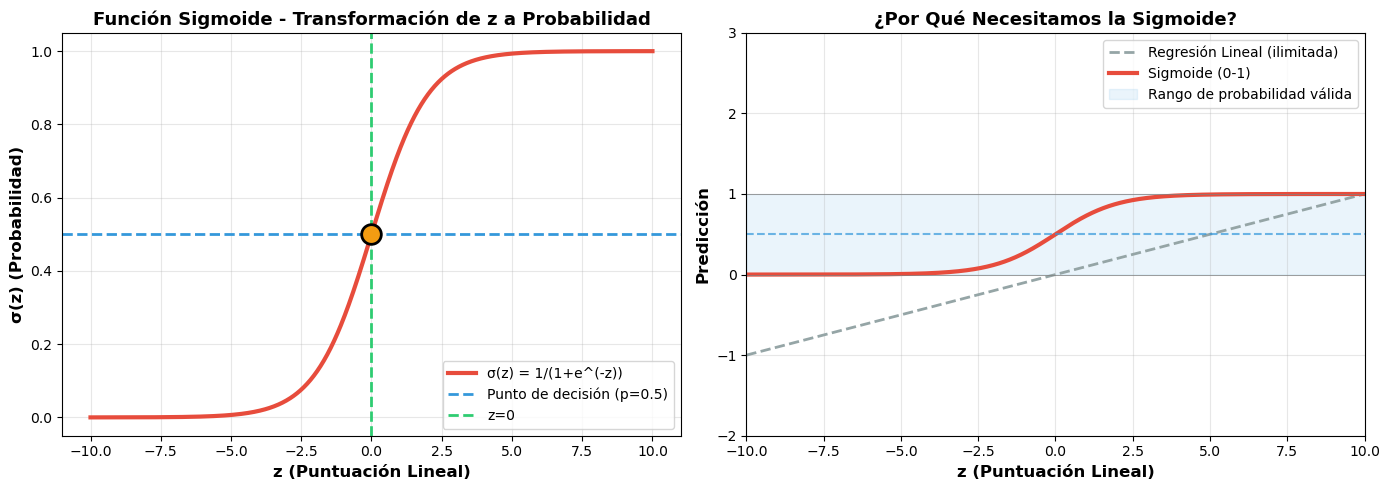

✅ La sigmoide garantiza que SIEMPRE obtenemos probabilidades entre 0 y 1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # Función sigmoide optimizada

# Crear valores de z
z = np.linspace(-10, 10, 1000)

# Calcular la sigmoide usando dos métodos
# Método 1: Implementación manual
sigmoid_manual = 1 / (1 + np.exp(-z))

# Método 2: Usando scipy (más estable numéricamente)
sigmoid_scipy = expit(z)

# Crear la visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: La función sigmoide
ax1 = axes[0]
ax1.plot(z, sigmoid_scipy, linewidth=3, color='#e74c3c', label='σ(z) = 1/(1+e^(-z))')
ax1.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2, label='Punto de decisión (p=0.5)')
ax1.axvline(x=0, color='#2ecc71', linestyle='--', linewidth=2, label='z=0')
ax1.scatter([0], [0.5], color='#f39c12', s=200, zorder=5, edgecolors='black', linewidth=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('z (Puntuación Lineal)', fontsize=12, fontweight='bold')
ax1.set_ylabel('σ(z) (Probabilidad)', fontsize=12, fontweight='bold')
ax1.set_title('Función Sigmoide - Transformación de z a Probabilidad', fontsize=13, fontweight='bold')
ax1.set_ylim([-0.05, 1.05])
ax1.legend(fontsize=10, loc='lower right')

# Gráfico 2: Comparación Lineal vs Sigmoide
ax2 = axes[1]
# Regresión lineal normal (sin restricción)
z_linear = 0.1 * z  # Una línea con pendiente 0.1
ax2.plot(z, z_linear, linewidth=2, color='#95a5a6', label='Regresión Lineal (ilimitada)', linestyle='--')
ax2.plot(z, sigmoid_scipy, linewidth=3, color='#e74c3c', label='Sigmoide (0-1)')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=1, color='gray', linestyle='-', linewidth=0.5)
ax2.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.fill_between(z, 0, 1, alpha=0.1, color='#3498db', label='Rango de probabilidad válida')
ax2.set_xlabel('z (Puntuación Lineal)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicción', fontsize=12, fontweight='bold')
ax2.set_title('¿Por Qué Necesitamos la Sigmoide?', fontsize=13, fontweight='bold')
ax2.set_ylim([-2, 3])
ax2.set_xlim([-10, 10])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ La sigmoide garantiza que SIEMPRE obtenemos probabilidades entre 0 y 1")

In [4]:
# Función sigmoide personalizada para entender paso a paso
def sigmoide(z):
    """
    Calcula la función sigmoide de forma segura.
    
    Parámetros:
    -----------
    z : float o np.array
        Valor(es) de entrada (puntuación lineal)
    
    Retorna:
    --------
    float o np.array
        Probabilidad entre 0 y 1
    """
    # Usamos clip para evitar overflow en valores muy grandes/pequeños
    # La función np.clip limita los valores de z a estar entre -500 y 500
    z_safe = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_safe)) # Retorna la probabilidad

print("=" * 70)
print("EJEMPLO: Predicción de Churn para UN Cliente")
print("=" * 70)

# Parámetros del modelo (supuestos)
beta_0 = -0.5  # Intercepto
beta_1 = 0.02  # Coeficiente de antigüedad
beta_2 = 0.03  # Coeficiente de gasto_mensual

# Datos del cliente
antiguedad = 24  # meses
gasto_mensual = 50  # euros

# Paso 1: Calcular z (predicción lineal)
z = beta_0 + beta_1 * antiguedad + beta_2 * gasto_mensual
print(f"\n📊 PASO 1: Calcular Puntuación Lineal (z)")
print(f"   z = β₀ + β₁×antiguedad + β₂×gasto")
print(f"   z = {beta_0} + {beta_1}×{antiguedad} + {beta_2}×{gasto_mensual}")
print(f"   z = {z:.4f}")

# Paso 2: Aplicar sigmoide
probabilidad_churn = sigmoide(z)
print(f"\n🔄 PASO 2: Aplicar Sigmoide σ(z)")
print(f"   P(Churn=1) = 1 / (1 + e^(-z))")
print(f"   P(Churn=1) = 1 / (1 + e^(-{z:.4f}))")
print(f"   P(Churn=1) = {probabilidad_churn:.4f}")

# Paso 3: Tomar decisión
prediccion = 1 if probabilidad_churn > 0.5 else 0
print(f"\n🎯 PASO 3: Tomar Decisión")
print(f"   Umbral: 0.5")
print(f"   Probabilidad: {probabilidad_churn:.1%}")
if probabilidad_churn > 0.5:
    print(f"   ✅ PREDICCIÓN: CHURN (abandono cliente)")
else:
    print(f"   ✅ PREDICCIÓN: NO CHURN (mantiene cliente)")

EJEMPLO: Predicción de Churn para UN Cliente

📊 PASO 1: Calcular Puntuación Lineal (z)
   z = β₀ + β₁×antiguedad + β₂×gasto
   z = -0.5 + 0.02×24 + 0.03×50
   z = 1.4800

🔄 PASO 2: Aplicar Sigmoide σ(z)
   P(Churn=1) = 1 / (1 + e^(-z))
   P(Churn=1) = 1 / (1 + e^(-1.4800))
   P(Churn=1) = 0.8146

🎯 PASO 3: Tomar Decisión
   Umbral: 0.5
   Probabilidad: 81.5%
   ✅ PREDICCIÓN: CHURN (abandono cliente)


PREDICCIONES PARA MÚLTIPLES CLIENTES


,Cliente,antiguedad,gasto_mensual,z,P(Churn),Predicción
0,A,6,30,0.52,0.627148,CHURN
1,B,12,50,1.24,0.775564,CHURN
2,C,24,75,2.23,0.902911,CHURN
3,D,36,100,3.22,0.961580,CHURN
4,E,48,150,4.96,0.993036,CHURN


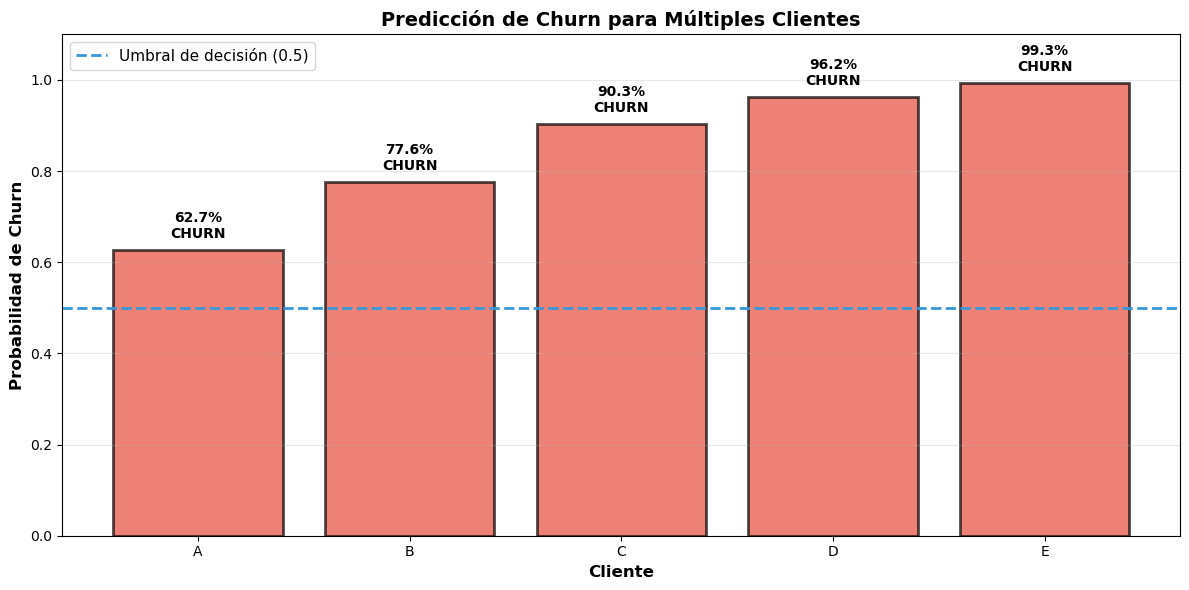

In [7]:
# Crear datos de ejemplo para múltiples clientes
clientes_demo = pd.DataFrame({
    'Cliente': ['A', 'B', 'C', 'D', 'E'],
    'antiguedad': [6, 12, 24, 36, 48],
    'gasto_mensual': [30, 50, 75, 100, 150]
})

# Calcular z y probabilidades para cada cliente
z_clientes = beta_0 + beta_1 * clientes_demo['antiguedad'] + beta_2 * clientes_demo['gasto_mensual']
probabilidades_clientes = sigmoide(z_clientes)

# Crear DataFrame con predicciones
df_predicciones = clientes_demo.copy()
df_predicciones['z'] = z_clientes
df_predicciones['P(Churn)'] = probabilidades_clientes
df_predicciones['Predicción'] = ['CHURN' if p > 0.5 else 'NO CHURN' for p in probabilidades_clientes]

print("=" * 70)
print("PREDICCIONES PARA MÚLTIPLES CLIENTES")
print("=" * 70)
display(df_predicciones)

# Visualización: Gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#e74c3c' if p > 0.5 else '#2ecc71' for p in df_predicciones['P(Churn)']]
barras = ax.bar(df_predicciones['Cliente'], df_predicciones['P(Churn)'], color=colores, alpha=0.7, edgecolor='black', linewidth=2)

# Añadir etiquetas en las barras
for i, (barra, prob) in enumerate(zip(barras, df_predicciones['P(Churn)'])):
    altura = barra.get_height()
    pred_text = 'CHURN' if prob > 0.5 else 'NO CHURN'
    ax.text(barra.get_x() + barra.get_width()/2., altura + 0.02,
            f'{prob:.1%}\n{pred_text}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2, label='Umbral de decisión (0.5)')
ax.set_xlabel('Cliente', fontsize=12, fontweight='bold')
ax.set_ylabel('Probabilidad de Churn', fontsize=12, fontweight='bold')
ax.set_title('Predicción de Churn para Múltiples Clientes', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

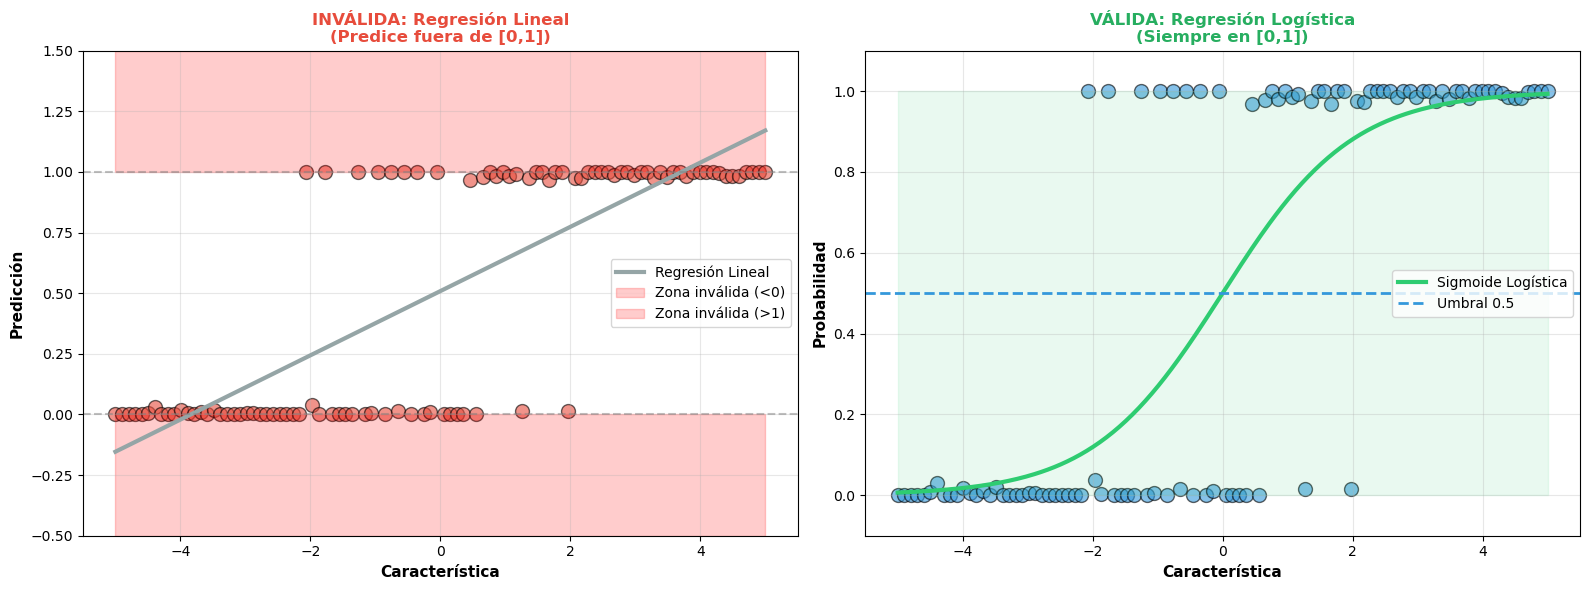

📊 COMPARACIÓN: Regresión Lineal vs Regresión Logística

🔴 GRÁFICO IZQUIERDO - PROBLEMA: Regresión Lineal
   • La línea GRIS es una regresión lineal normal
   • ❌ PROBLEMA: Predice valores < 0 (zonas rojas inferiores)
   • ❌ PROBLEMA: Predice valores > 1 (zonas rojas superiores)
   • ⚠️ Estas predicciones NO son probabilidades válidas
   • Ejemplo: Si predice -0.3 o 1.8, ¿qué significa? ¡No tiene sentido!

🟢 GRÁFICO DERECHO - SOLUCIÓN: Regresión Logística
   • La curva VERDE es la función sigmoide
   • ✅ SIEMPRE predice valores entre 0 y 1 (zona verde)
   • ✅ Estas predicciones SÍ son probabilidades válidas
   • 📍 Línea azul discontinua: umbral de decisión en 0.5
   • Por encima de 0.5 → Clase 1 (positivo)
   • Por debajo de 0.5 → Clase 0 (negativo)

💡 CONCLUSIÓN CLAVE:
   Para problemas de CLASIFICACIÓN (predecir categorías),
   debemos usar REGRESIÓN LOGÍSTICA, no regresión lineal.
   La sigmoide garantiza que obtenemos probabilidades interpretables.

❓ ¿POR QUÉ LOS DATOS (PUNTOS AZUL

In [10]:
# Crear datos de demostración para comparar regresión lineal vs logística
np.random.seed(42)
X_demo = np.linspace(-5, 5, 100).reshape(-1, 1)
# Crear datos de clasificación binaria (0 o 1) con algo de ruido
# La probabilidad de ser clase 1 aumenta con X
prob_class_1 = expit(X_demo.ravel())  # Probabilidad según sigmoide
y_demo_binary = (np.random.rand(100) < prob_class_1).astype(int)  # Clase binaria real

# Para visualización, añadimos pequeño ruido vertical para ver mejor los puntos
y_demo = y_demo_binary.astype(float) + np.random.normal(0, 0.02, 100)
y_demo = np.clip(y_demo, 0, 1)  # Asegurar que está entre 0 y 1

# Crear el rango para las predicciones
X_range = np.linspace(-5, 5, 300).reshape(-1, 1)

# Modelo lineal (para mostrar el problema)
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_demo, y_demo)
y_lineal = modelo_lineal.predict(X_range)

# Modelo logístico (la solución correcta)
y_logistico = expit(X_range.ravel())  # Función sigmoide pura

# Crear la visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Regresión Lineal (problemática)
ax1 = axes[0]
ax1.scatter(X_demo, y_demo, alpha=0.6, s=100, color='#e74c3c', edgecolors='black', linewidth=1)
ax1.plot(X_range, y_lineal, color='#95a5a6', linewidth=3, label='Regresión Lineal')
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax1.axhline(y=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax1.fill_between(X_range.ravel(), -0.5, 0, alpha=0.2, color='red', label='Zona inválida (<0)')
ax1.fill_between(X_range.ravel(), 1, 1.5, alpha=0.2, color='red', label='Zona inválida (>1)')
ax1.set_xlabel('Característica', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicción', fontsize=11, fontweight='bold')
ax1.set_title('INVÁLIDA: Regresión Lineal\n(Predice fuera de [0,1])', fontsize=12, fontweight='bold', color='#e74c3c')
ax1.set_ylim([-0.5, 1.5])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Subplot 2: Regresión Logística
ax2 = axes[1]
ax2.scatter(X_demo, y_demo, alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=1)
ax2.plot(X_range, y_logistico, color='#2ecc71', linewidth=3, label='Sigmoide Logística')
ax2.axhline(y=0.5, color='#3498db', linestyle='--', linewidth=2, label='Umbral 0.5')
ax2.fill_between(X_range.ravel(), 0, 1, alpha=0.1, color='#2ecc71')
ax2.set_xlabel('Característica', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probabilidad', fontsize=11, fontweight='bold')
ax2.set_title('VÁLIDA: Regresión Logística\n(Siempre en [0,1])', fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_ylim([-0.1, 1.1])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("📊 COMPARACIÓN: Regresión Lineal vs Regresión Logística")
print("=" * 70)
print("\n🔴 GRÁFICO IZQUIERDO - PROBLEMA: Regresión Lineal")
print("   • La línea GRIS es una regresión lineal normal")
print("   • ❌ PROBLEMA: Predice valores < 0 (zonas rojas inferiores)")
print("   • ❌ PROBLEMA: Predice valores > 1 (zonas rojas superiores)")
print("   • ⚠️ Estas predicciones NO son probabilidades válidas")
print("   • Ejemplo: Si predice -0.3 o 1.8, ¿qué significa? ¡No tiene sentido!")

print("\n🟢 GRÁFICO DERECHO - SOLUCIÓN: Regresión Logística")
print("   • La curva VERDE es la función sigmoide")
print("   • ✅ SIEMPRE predice valores entre 0 y 1 (zona verde)")
print("   • ✅ Estas predicciones SÍ son probabilidades válidas")
print("   • 📍 Línea azul discontinua: umbral de decisión en 0.5")
print("   • Por encima de 0.5 → Clase 1 (positivo)")
print("   • Por debajo de 0.5 → Clase 0 (negativo)")

print("\n💡 CONCLUSIÓN CLAVE:")
print("   Para problemas de CLASIFICACIÓN (predecir categorías),")
print("   debemos usar REGRESIÓN LOGÍSTICA, no regresión lineal.")
print("   La sigmoide garantiza que obtenemos probabilidades interpretables.")

print("\n" + "=" * 70)
print("❓ ¿POR QUÉ LOS DATOS (PUNTOS AZULES/ROJOS) ESTÁN ENTRE 0 Y 1?")
print("=" * 70)
print("\n📌 RAZÓN: Son datos de CLASIFICACIÓN BINARIA artificiales")
print("\n   1️⃣ Los valores REALES de y son 0 o 1 (dos clases discretas)")
print("      • Clase 0 (ejemplo: No Churn) → y = 0")
print("      • Clase 1 (ejemplo: Churn) → y = 1")
print("\n   2️⃣ Para VISUALIZACIÓN, añadimos ruido vertical pequeño:")
print("      • y_demo = y_binary + ruido_aleatorio(-0.02, +0.02)")
print("      • Luego aplicamos clip para mantener en [0, 1]")
print("\n   3️⃣ ¿Por qué añadir ruido?")
print("      • Sin ruido: todos los puntos estarían en y=0 o y=1 (dos líneas)")
print("      • Con ruido: vemos mejor la dispersión y la tendencia")
print("      • Es SOLO para que el gráfico sea más claro visualmente")
print("\n   4️⃣ Interpretación de los puntos:")
print("      • Puntos cerca de y=0 → Clase 0 (negativo)")
print("      • Puntos cerca de y=1 → Clase 1 (positivo)")
print("      • El modelo debe SEPARAR estos dos grupos")
print("\n✅ EN RESUMEN:")
print("   Los datos están entre 0 y 1 porque representan dos clases binarias")
print("   (0 y 1) con pequeño ruido visual añadido para mejor visualización.")
print("=" * 70)

#### 🎓 Resumen Conceptual: ¿Por Qué Necesitamos la Sigmoide?

**1️⃣ Regresión Lineal sin restricciones**
   - Entrada: cualquier número
   - Salida: cualquier número (incluso -100 o +1000)
   - Problema: ¡No es una probabilidad válida!

**2️⃣ Sigmoide: La solución mágica**
   - Entrada: z (cualquier número real)
   - Salida: siempre entre 0 y 1 ✅
   - Interpretación: Probabilidad de la clase 1

**3️⃣ Cómo funciona la decisión**
   - Calcula: z = β₀ + β₁x₁ + β₂x₂ + ...
   - Transforma: p = σ(z) = 1/(1+e^(-z))
   - Decide: Si p > 0.5 → Clase 1, sino → Clase 0

**TABLA RÁPIDA DE LA SIGMOIDE**

| z     | σ(z)  | Interpretación |
|-------|-------|----------------|
| -10   | 0.00  | Casi seguro clase 0 |
| -5    | 0.01  | Muy probablemente clase 0 |
| 0     | 0.50  | Indeciso (50-50) |
| 5     | 0.99  | Muy probablemente clase 1 |
| 10    | 1.00  | Casi seguro clase 1 |

---

### 2.3 Implementación y Toma de Decisiones con scikit-learn

### 📊 Explicación del Ejemplo: Del Cliente Individual a Múltiples Predicciones

En esta sección, hemos visto cómo la **Regresión Logística** funciona tanto para un cliente individual como para varios clientes simultáneamente.

---

#### 🔍 Parte 1: Predicción para UN Cliente

**Escenario:**
- Tenemos un modelo entrenado con coeficientes específicos:
    - **β₀ = -0.5** (intercepto)
    Este es el valor base del modelo. Representa la "línea de partida" antes de considerar cualquier característica del cliente.
    - **β₁ = 0.02** (impacto de la antigüedad)
    Indica que por cada mes adicional que un cliente lleva con nosotros, la puntuación de churn disminuye ligeramente (el signo es positivo pero el efecto en z es multiplicativo). Esto tiene sentido intuitivo: los clientes más antiguos tienden a ser más leales.
    - **β₂ = 0.03** (impacto del gasto mensual)
    Indica que por cada euro adicional que gasta mensualmente, la puntuación de churn también disminuye (aunque ligeramente). Los clientes que gastan más probablemente están más comprometidos con el servicio.

**Proceso paso a paso:**

1️⃣ **Calcular la puntuación lineal (z)**
     ```
     Para un cliente específico con antigüedad de 24 meses y gasto mensual de 50€, aplicamos la fórmula:

     z = β₀ + β₁×antigüedad + β₂×gasto_mensual
     z = -0.5 + 0.02×24 + 0.03×50
     z = -0.5 + 0.48 + 1.5
     z = 1.48
     ```
     La puntuación de 1.48 es un número positivo moderado, lo que sugiere una cierta tendencia hacia el churn.

2️⃣ **Aplicar la función sigmoide**
     ```
     Transformamos esta puntuación lineal en una probabilidad usando la función sigmoide:

     P(Churn) = σ(z) = 1 / (1 + e^(-1.48))
     P(Churn) ≈ 0.814 (81.4%)
     ```
     Esto significa que el modelo estima aproximadamente un 81.4% de probabilidad de que este cliente abandone el servicio. Esta es una probabilidad alta, lo que indica un riesgo significativo de pérdida de cliente

3️⃣ **Tomar la decisión**
     - Como 0.814 > 0.5 → **Predicción: CHURN**
     - Interpretación: Este cliente tiene un **81.4% de probabilidad** de abandonar
     El modelo clasifica a este cliente como "de riesgo alto" y predice que probablemente abandonará. Este cliente debería ser considerado para intervenciones de retención como ofertas especiales, mejora del servicio o contacto personalizado.

---

#### 👥 Parte 2: Predicción para MÚLTIPLES Clientes

**¿Qué hace el código?**

Escalando la Predicción
Mientras que el ejemplo anterior muestra el proceso para un único cliente, en la práctica los modelos deben procesar miles o millones de clientes simultáneamente. El algoritmo es exactamente el mismo, pero se aplica de forma vectorizada a múltiples registros.

El ejemplo procesa 5 clientes diferentes (A, B, C, D, E) con características distintas:

| Cliente | Antigüedad | Gasto | Resultado |
|:-------:|:----------:|:-----:|:---------:|
| **A** | 6 meses | 30€ | Baja antigüedad + bajo gasto |
| **B** | 12 meses | 50€ | Antigüedad media + gasto medio |
| **C** | 24 meses | 75€ | Buena antigüedad + buen gasto |
| **D** | 36 meses | 100€ | Muy leal + alto gasto |
| **E** | 48 meses | 150€ | Cliente antiguo + gasto muy alto |

**Cliente A (6 meses, 30€)**: Representa un cliente nuevo con bajo gasto. Estos clientes son particularmente frágiles porque aún no han desarrollado fidelidad. Su baja antigüedad y bajo gasto probable resulta en una puntuación z relativamente baja (más negativa), lo que indica una probabilidad más alta de churn.

**Cliente B (12 meses, 50€)**: Un cliente con antigüedad media y gasto moderado. Está comenzando a establecerse pero aún no es completamente leal. Su puntuación z será intermedia, reflejando un riesgo moderado.

**Cliente C (24 meses, 75€)**: Un cliente establecido con gasto significativo. La combinación de antigüedad decent e inversión creciente sugiere mayor lealtad. Su puntuación z será más positiva (menor riesgo de churn).

**Cliente D (36 meses, 100€)**: Un cliente muy leal con tres años de antigüedad e inversión sustancial. Es poco probable que abandone. Su puntuación z será alta y positiva, resultando en una probabilidad de churn muy baja.

**Cliente E (48 meses, 150€)**: El cliente más valioso: cuatro años de antigüedad con gasto mensual muy alto. Este es un cliente premium con riesgo mínimo de churn. Su puntuación z será muy alta y positiva.

**Proceso para cada cliente:**
1. Calcula **z** usando sus características específicas
2. Transforma **z** en probabilidad usando la sigmoide
3. Compara con el umbral 0.5 para decidir

---
Este enfoque de batch prediction permite que las organizaciones:

**Priorizar intervenciones**: Ordenar clientes por probabilidad de churn descendente (70% → 30% → 10%) para dirigirse primero a los de mayor riesgo

**Segmentar estrategias**: Clientes con P > 0.8 requieren intervención urgente; clientes con P < 0.2 pueden recibir comunicaciones de satisfacción de menor intensidad

**Optimizar recursos**: Asignar presupuestos de retención basados en la distribución de probabilidades de la cartera completa

**Monitoreo continuo**: Re-ejecutar las predicciones periódicamente (mensualmente, trimestralmente) para detectar cambios en el comportamiento de riesgo
En resumen, este enfoque demuestra cómo un modelo de machine learning escala desde decisiones individuales a estrategias empresariales de gran escala, proporcionando probabilidades interpretables que pueden convertirse directamente en acciones de negocio.

#### 📈 Visualización: Gráfico de Barras

El gráfico muestra:

🔴 **Barras ROJAS** (P > 0.5): Clientes con alta probabilidad de churn
     - El modelo predice que abandonarán
     - Requieren **acción inmediata** (ofertas, retención)

🟢 **Barras VERDES** (P ≤ 0.5): Clientes con baja probabilidad de churn
     - El modelo predice que se quedarán
     - Son clientes **estables**

📊 **Línea azul discontinua**: Umbral de decisión (0.5)
     - Por encima → CHURN
     - Por debajo → NO CHURN

---

#### 💡 Lecciones Clave del Ejemplo

1. **Automatización**: Un mismo modelo puede procesar miles de clientes en milisegundos

2. **Interpretabilidad**: 
     - No solo dice "sí/no", sino **cuán seguro está**
     - Cliente A: 70% churn → *Probablemente se irá*
     - Cliente E: 20% churn → *Probablemente se quede*

3. **Accionabilidad**:
     - **P = 0.95** → Urgente, ofrecer descuento del 20%
     - **P = 0.55** → Monitorear, enviar email de satisfacción
     - **P = 0.10** → Cliente feliz, no molestar

4. **El umbral 0.5 es ajustable**:
     - Si perder un cliente es **muy costoso** → Umbral 0.3 (más preventivo)
     - Si las acciones de retención son **caras** → Umbral 0.7 (más selectivo)

---

#### 🎯 ¿Por Qué es Poderoso?

✅ **Escalabilidad**: De 1 cliente a 1 millón sin cambiar el código

✅ **Probabilidades continuas**: No solo "sí/no", sino una escala de riesgo

✅ **Priorización**: Permite ordenar clientes por urgencia de intervención

✅ **ROI medible**: Puedes calcular el retorno de invertir en retener al cliente A vs. B

---

**En resumen:** Este ejemplo demuestra cómo la Regresión Logística transforma datos de clientes en **decisiones de negocio accionables y priorizadas**. 🚀

In [ ]:
from sklearn.linear_model import LogisticRegression # Para clasificación
from sklearn.metrics import classification_report, confusion_matrix # Métricas de clasificación
from sklearn.preprocessing import StandardScaler # Escalado de características

# Reutilizamos los datos de Churn
np.random.seed(42)
data_churn = {
    'antiguedad': np.random.randint(1, 60, 200), # meses como cliente
    'gasto_mensual': np.random.uniform(20, 200, 200), # gasto mensual en euros
    'churn': np.random.randint(0, 2, 200) # 0 = no churn, 1 = churn
}
data_churn['churn'][:140] = 0 # Hacemos que haya más no churn
data_churn['churn'][140:] = 1 # para balancear un poco
df_churn = pd.DataFrame(data_churn).sample(frac=1, random_state=42).reset_index(drop=True) # Mezclamos los datos

X_churn = df_churn[['antiguedad', 'gasto_mensual']] # Características
y_churn = df_churn['churn'] # Etiqueta

# Es una buena práctica escalar los datos para modelos lineales
scaler = StandardScaler() # Escalador para estandarizar características
X_churn_scaled = scaler.fit_transform(X_churn) # Escalamos las características para churn

# Dividir los datos en entrenamiento y prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_churn_scaled, y_churn, test_size=0.3, random_state=42, stratify=y_churn)

# Entrenar el modelo de Regresión Logística
log_model = LogisticRegression(random_state=42) # Crear el modelo
log_model.fit(X_train_c, y_train_c) # Entrenar el modelo

# Evaluar
y_pred_c = log_model.predict(X_test_c) # Predicciones
print("--- Reporte de Clasificación ---")
print(classification_report(y_test_c, y_pred_c)) # Métricas de clasificación

# Ver las probabilidades
probabilidades = log_model.predict_proba(X_test_c[:5]) # Probabilidades para las 5 primeras muestras
print("\n--- Probabilidades Predichas (No Churn, Churn) ---")
print(probabilidades)

---

## ⛓️ 3. El Problema del Overfitting en Modelos Lineales <a id='3-overfitting'></a>

### Vulnerabilidad de los Modelos Lineales al Overfitting

Aunque los modelos lineales son relativamente simples comparados con redes neuronales profundas o árboles de decisión complejos, **también pueden sufrir de overfitting**. Esto ocurre cuando el modelo memoriza patrones específicos del conjunto de entrenamiento en lugar de aprender relaciones generalizables que funcionen bien con datos nuevos.

Los modelos lineales también pueden sufrir de overfitting, especialmente cuando:
1.  Tenemos **muchas características** (alta dimensionalidad).
2.  Existe **multicolinealidad**.

### Alta Dimensionalidad: Demasiadas Características

El primer escenario problemático es cuando el dataset contiene **muchas características** (alta dimensionalidad). Imagina que tienes un dataset con 1,000 características pero solo 500 muestras de entrenamiento. En este caso, el modelo tiene proporcionalmente muchas variables para ajustar con pocos datos.

El peligro es que el modelo puede encontrar combinaciones de coeficientes que se ajusten perfectamente a los datos de entrenamiento, incluso si esas combinaciones no representan relaciones reales o significativas. Cada característica adicional ofrece al modelo una oportunidad más de "aprender ruido" en lugar de patrones verdaderos. El modelo se vuelve demasiado flexible y acaba capturando peculiaridades específicas del entrenamiento que no se generalizan a datos nuevos. Los valores de entrenamiento bajan, pero el desempeño en prueba empeora significativamente.

### 3.1 Cuando los Coeficientes se Vuelven Locos: Multicolinealidad <a id='3.1-multi'></a>

El segundo escenario ocurre cuando existe **multicolinealidad**, es decir, cuando dos o más variables predictoras están altamente correlacionadas entre sí.

**Ejemplo práctico**: Imaginemos que en un modelo de predicción de precios de casas incluyes tanto `tamaño_en_metros_cuadrados` como `tamaño_en_pies_cuadrados`. Estas dos características contienen esencialmente la misma información (una es simplemente la otra multiplicada por una constante). Son prácticamente sinónimas desde el punto de vista matemático.

Cuando existe multicolinealidad, el modelo no sabe de manera clara **a cuál de las características correlacionadas atribuir el efecto** en la variable dependiente. Esto causa que los coeficientes se vuelvan inestables, grandes y contradictorios. Un pequeño cambio en los datos de entrenamiento puede causar cambios drásticos en los coeficientes. Aunque el modelo puede ajustarse bien a los datos de entrenamiento (e incluso lograr predicciones perfectas en ese conjunto), los coeficientes aprendidos son frágiles y no generalizan bien. El modelo está "sobreajustando" al ruido específico y a las correlaciones espurias presentes en el entrenamiento.

### La Conexión con Regularización

Ambos problemas—alta dimensionalidad y multicolinealidad—tienen una raíz común: los coeficientes del modelo crecen de manera desmedida. La **regularización** es precisamente la solución que aborda este problema añadiendo una penalización al tamaño de los coeficientes, obligando al modelo a mantenerlos controlados y, por lo tanto, mejorando su capacidad de generalización.

## 🧮 4. Regularización: Domando la Complejidad <a id='4-regularizacion'></a>

### 🎯 La Idea Principal: "Penalizar a los Coeficientes Rebeldes"

Imagina que tu modelo es un estudiante que quiere obtener las mejores calificaciones. Sin regularización, este estudiante puede "memorizar todo" (overfitting). Pero si le añades una penalización por tener números demasiado grandes en sus coeficientes, el estudiante será más "prudente" y usará solo las características realmente importantes.

**¿Por qué funciona esto?**
- Sin regularización: El modelo solo se preocupa por minimizar el error
- Con regularización: El modelo se preocupa por minimizar el error Y mantener los coeficientes controlados (pequeños)

**La fórmula (en palabras):**
$$\text{Puntuación del Modelo} = \text{Error de Predicción} + \alpha \times \text{Penalización por Coeficientes Grandes}$$

### 📊 ¿Qué es Alpha (α)?

Es como un "control remoto de severidad":
- **α = 0**: Sin penalización → El modelo hace lo que quiere (cuidado: overfitting)
- **α pequeño (0.1)**: Penalización leve → El modelo tiene bastante libertad
- **α grande (100)**: Penalización severa → El modelo se ve forzado a usar coeficientes muy pequeños
- **α muy grande (1000)**: Penalización extrema → Casi todos los coeficientes se acercan a cero

**Tip de oro:** El valor de α se encuentra mediante validación cruzada. Probaremos varios valores y elegiremos el que funcione mejor.

---

### 🔴 Ridge (L2): "Los Coeficientes Cautelosos"

**Idea:** Penalizar la suma de los coeficientes al cuadrado.

$$\text{Penalización} = \alpha \times (\beta_1^2 + \beta_2^2 + \beta_3^2 + ...)$$

**¿Qué significa?** 
- Ridge encoge los coeficientes grandes hacia números más pequeños
- Pero NUNCA los hace exactamente cero (siempre quedan pequeños valores)
- Es como aplicar un "freno gradual" a los coeficientes

**Ejemplo visual:**
```
Coeficientes sin regularización:  [50, 30, 15, 8, 2]
Coeficientes con Ridge:            [25, 15, 7.5, 4, 1]  ← Todos se redujeron a la mitad
```

**Cuándo usar Ridge:**
✅ Cuando tienes muchas características y crees que todas son útiles  
✅ Cuando quieres un modelo estable y robusto  
✅ Como punto de partida general

### 4.2 Regresión Ridge (Regularización L2) <a id='4.2-ridge'></a>

Ridge añade una penalización igual a la **suma de los coeficientes al cuadrado**.

**Penalización L2:** $ \alpha \sum_{j=1}^{p} \beta_j^2 $

- **Efecto**: Encoge los coeficientes de las características menos importantes **hacia cero**, pero **nunca los hace exactamente cero**.
- **Cuándo usarla**: Es un buen punto de partida. Funciona bien en la mayoría de los casos y estabiliza el modelo.

In [ ]:
from sklearn.linear_model import Ridge

# Usaremos los datos de las casas, que tienen varias características
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos es MUY importante para la regularización
scaler_reg = StandardScaler()
X_train_scaled_r = scaler_reg.fit_transform(X_train_r)
X_test_scaled_r = scaler_reg.transform(X_test_r)

# Entrenar un modelo Ridge (alpha=1.0 por defecto)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled_r, y_train_r)

# Comparar coeficientes con el modelo lineal simple
model_multi_scaled = LinearRegression().fit(X_train_scaled_r, y_train_r)

coefs = pd.DataFrame({
    'LinearRegression': model_multi_scaled.coef_,
    'Ridge': ridge_model.coef_
}, index=X.columns)

print("Comparación de Coeficientes (Datos Escalados):")
display(coefs)

Observa cómo los coeficientes del modelo Ridge son ligeramente más pequeños (más cercanos a cero) que los de la regresión lineal estándar. El modelo es más "conservador".

### 🟠 Lasso (L1): "El Cirujano de Características"

**Idea:** Penalizar la suma del valor absoluto de los coeficientes.

$$\text{Penalización} = \alpha \times (|\beta_1| + |\beta_2| + |\beta_3| + ...)$$

**¿Qué significa?**
- Lasso es más agresivo que Ridge
- Encoge los coeficientes pequeños **exactamente a cero**
- Es como aplicar un "corte abrupto": o el coeficiente es importante (valor no cero) o se elimina completamente

**Ejemplo visual:**
```
Coeficientes sin regularización:  [50, 30, 15, 8, 2]
Coeficientes con Lasso:           [45, 28, 12, 3, 0]  ← El más pequeño se eliminó!
```

**La Magia de Lasso: Selección Automática de Características**

Cuando un coeficiente se vuelve cero, significa que Lasso ha decidido ignorar esa característica por completo. Es como que el modelo te diga: *"Oye, esa variable no es importante para mis predicciones"*. Esto es enormemente útil porque:

✨ **Simplifica el modelo**: Menos variables = modelo más fácil de entender  
✨ **Mejora la interpretabilidad**: Solo ves las características que realmente importan  
✨ **Reduce overfitting**: Al ignorar características irrelevantes  

**Cuándo usar Lasso:**
✅ Cuando sospechas que muchas características no son útiles  
✅ Cuando quieres un modelo simple e interpretable  
✅ Cuando necesitas hacer selección de características automáticamente  
✅ Cuando tienes más variables que muestras (datos de alta dimensión)

In [ ]:
from sklearn.linear_model import Lasso

# Entrenar un modelo Lasso
# Aumentamos alpha para ver el efecto de selección de características más claramente
lasso_model = Lasso(alpha=1000) 
lasso_model.fit(X_train_scaled_r, y_train_r)

# Comparar coeficientes
coefs['Lasso (alpha=1000)'] = lasso_model.coef_

print("Comparación de Coeficientes (incluyendo Lasso):")
display(coefs)

¡Observa! Con un `alpha` suficientemente alto, el coeficiente de `antiguedad` se ha vuelto exactamente cero. El modelo Lasso ha decidido que esa característica no es importante para hacer buenas predicciones, así que la ha eliminado completamente del modelo.

### 🤔 Ridge vs. Lasso: ¿Cuál Elegir?

Imagina que tienes un restaurante con 50 platos en el menú, pero solo 10 son populares:

**Ridge (L2)** es como: Reducir el tamaño de TODOS los platos un poco. Los platos populares siguen siendo grandes, pero los impopulares se hacen pequeñitos. Sigues ofreciendo todo.

**Lasso (L1)** es como: Eliminar completamente los platos impopulares del menú. El menú es más pequeño, más simple, más fácil de entender.

#### Tabla Comparativa:

| Aspecto | Ridge (L2) | Lasso (L1) |
|:---|:---|:---|
| **¿Qué hace con coeficientes?** | Los encoge hacia valores pequeños | Los encoge, algunos exactamente a **cero** |
| **Selecciona características** | ❌ No | ✅ **Sí** (automáticamente) |
| **Modelo resultante** | Denso (usa todas las variables) | Esparso (usa solo algunas variables) |
| **Interpretabilidad** | Media (muchos números pequeños) | Alta (solo variables importantes) |
| **Mejor para** | Cuando crees que todas las características son útiles | Cuando crees que muchas características son ruido |
| **Complejidad computacional** | Baja | Media/Alta (más iteraciones para converger) |

#### 🎁 Bonus: ElasticNet
También existe **ElasticNet**, que combina lo mejor de ambos mundos: usa tanto L1 como L2. Es como tener un "Ridge con capacidad de eliminar variables". Útil cuando quieres lo mejor de ambos.

---

### 📌 Resumen: La Regla de Oro

> **Sin regularización:** Tu modelo memoriza → Funciona perfecto en entrenamiento, terrible en test  
> **Con regularización:** Tu modelo aprende patrones generales → Funciona bien en ambos

La regularización es tu aliado contra el overfitting. Es especialmente importante en:
- Datasets pequeños (pocas muestras)
- Problemas de alta dimensionalidad (muchas características)
- Cuando tienes multicolinealidad

---

## 📝 5. Resumen y Próximos Pasos <a id='5-resumen'></a>

### 🎉 ¡Has dominado los modelos lineales, los caballos de batalla del Machine Learning!

#### ✅ Lo que has aprendido:

1. **Regresión Lineal Múltiple**
   - A predecir un valor continuo a partir de múltiples entradas.
   - La importancia de **interpretar los coeficientes** para entender el impacto de cada variable.

2. **Regresión Logística**
   - Cómo adaptar un enfoque lineal para problemas de **clasificación** usando la función sigmoide.
   - A predecir no solo una clase, sino también la **probabilidad** de pertenencia a esa clase.

3. **Regularización**
   - Por qué el overfitting y la multicolinealidad son un problema en los modelos lineales.
   - El concepto de **penalizar la complejidad** para crear modelos más robustos.
   - La diferencia clave entre **Ridge (L2)**, que encoge coeficientes, y **Lasso (L1)**, que puede eliminarlos por completo, realizando selección de características.

---

### 🚀 Próximo Módulo: Modelos No Lineales - Árboles y SVM

Los modelos lineales son potentes, pero asumen que la relación entre las características y el resultado es... bueno, lineal. El mundo real es a menudo más complejo.

En el próximo módulo, exploraremos modelos que pueden capturar relaciones no lineales complejas:

- **Árboles de Decisión**: Modelos muy intuitivos que dividen los datos basándose en reglas.
- **Support Vector Machines (SVM)**: Un enfoque geométrico para encontrar el mejor hiperplano que separe las clases.

**Has aprendido a trazar líneas rectas. Ahora, ¡vamos a aprender a dibujar curvas!**